# MIPAR Feature Measurement Analysis: GOO220\_51 / \_52 / \_53

Compares M23C6, MX, ZPhase, and Laves precipitate populations across three material states
measured by MIPAR image analysis.

**Workflow**
1. Preview the raw data with `stamp.io.load_mipar_features`.
2. Run the per-FOV statistics pipeline for each phase via `stamp.pipeline.run_mipar`.
3. Box plots — individual phase plots and a combined multi-panel figure.
4. Summary table — mean of per-FOV means and standard deviations for ECD.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import stamp.pipeline as pipeline
from stamp.io import load_mipar_features
from stamp.pipeline import run_mipar
from stamp.pipeline import _STATE_COLORS
from stamp.export import journal_style, figure_for, save, to_latex, NATURE

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("notebooks/data") if Path.cwd().name != "notebooks" else Path("data")
OUT_DIR  = DATA_DIR / "GOO220_mipar"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ECD_COL  = "Equivalent Diameter (um)"
AREA_COL = "Area (um^2)"

FILES = {
    "GOO220_51": DATA_DIR / "GOO220_51_FeatureMeas.csv",
    "GOO220_52": DATA_DIR / "GOO220_52_FeatureMeas.csv",
    "GOO220_53": DATA_DIR / "GOO220_53_FeatureMeas.csv",
}

# Display labels used on plot axes — edit here to switch between time,
# strain %, or any other descriptor without touching the plot cells.
STATE_LABELS = {
    "GOO220_51": "139 kh gauge",
    "GOO220_52": "139 kh thread",
    "GOO220_53": "139 kh fracture",
}

PHASES = ["M23C6", "MX", "ZPhase", "Laves"]
PHASE_ALIASES = {}

In [2]:
import os; print(os.getcwd())
DATA_DIR.exists()
FILES

C:\Users\westraadt.1\Repos\STAMP\notebooks


{'GOO220_51': WindowsPath('data/GOO220_51_FeatureMeas.csv'),
 'GOO220_52': WindowsPath('data/GOO220_52_FeatureMeas.csv'),
 'GOO220_53': WindowsPath('data/GOO220_53_FeatureMeas.csv')}

## 1. Preview raw data

In [3]:
for state, path in FILES.items():
    df = load_mipar_features(path)
    n_fovs   = df["Image"].nunique()
    n_feat   = len(df)
    phases   = sorted(df["Layer"].unique())
    print(f"{state}: {n_feat:,} features across {n_fovs} FOVs | phases: {phases}")

print()
display(load_mipar_features(FILES["GOO220_51"]).head(4))

GOO220_51: 8,812 features across 10 FOVs | phases: ['Laves', 'M23C6', 'MX', 'ZPhase']
GOO220_52: 10,911 features across 10 FOVs | phases: ['Laves', 'M23C6', 'MX', 'ZPhase']
GOO220_53: 9,884 features across 10 FOVs | phases: ['Laves', 'M23C6', 'MX', 'ZPhase']



,Image,Layer,Feature,Area (um^2),Area Fraction (%),Equivalent Diameter (um),CentroidX (um),CentroidY (um),Average Neighbor Distance (um)
0,T3_Mode2-GOO220_51_001_processed.tif,M23C6,1,0.001113,0.000393,0.037644,0.050309,9.479363,2.701132
1,T3_Mode2-GOO220_51_001_processed.tif,M23C6,2,0.015695,0.005542,0.141364,0.115385,0.861511,3.544124
2,T3_Mode2-GOO220_51_001_processed.tif,M23C6,3,0.001283,0.000453,0.040423,0.058274,12.925024,1.403527
3,T3_Mode2-GOO220_51_001_processed.tif,M23C6,4,0.004123,0.001456,0.072450,0.083414,13.260662,0.352284


## 2. Run per-FOV ECD pipeline for each phase

`run_mipar` reads each MIPAR CSV, filters to one phase, groups rows by FOV image,
and computes per-FOV statistics (arithmetic mean, geometric mean, median, CIs).

In [4]:
results_ecd = {}
for phase in PHASES:
    results_ecd[phase] = run_mipar(
        FILES,
        measurement=ECD_COL,
        unit="µm",
        phase=phase,
        phase_aliases=PHASE_ALIASES,
        missing_phase="warn",
        label=f"{phase} ECD",
        metric="amean",
    )
    n_fovs = len(results_ecd[phase].summary)
    print(f"{phase}: {n_fovs} FOV records ({n_fovs // len(FILES)} per state)")

print()
print("── Per-FOV summary (M23C6) ──")
display(
    results_ecd["M23C6"].summary[
        ["state", "fov", "n", "amean", "amean_std", "gmean", "median"]
    ].round(4)
)

M23C6: 30 FOV records (10 per state)
MX: 30 FOV records (10 per state)


ZPhase: 30 FOV records (10 per state)
Laves: 30 FOV records (10 per state)

── Per-FOV summary (M23C6) ──


,state,fov,n,amean,amean_std,gmean,median
0,GOO220_51,T3_Mode2-GOO220_51_001_processed,651,0.1232,0.0911,0.0875,0.1034
1,GOO220_51,T3_Mode2-GOO220_51_002_processed,765,0.1184,0.0782,0.0905,0.1048
2,GOO220_51,T3_Mode2-GOO220_51_003_processed,697,0.1274,0.0883,0.0965,0.1130
3,GOO220_51,T3_Mode2-GOO220_51_004_processed,813,0.1168,0.0826,0.0845,0.0989
4,GOO220_51,T3_Mode2-GOO220_51_006_processed,707,0.1219,0.0847,0.0926,0.1008
5,GOO220_51,T3_Mode2-GOO220_51_007_processed,478,0.1418,0.1142,0.1001,0.1162
6,GOO220_51,T3_Mode2-GOO220_51_008_processed,653,0.1307,0.0901,0.0971,0.1148
7,GOO220_51,T3_Mode2-GOO220_51_009_processed,713,0.1271,0.0832,0.1002,0.1101
8,GOO220_51,T3_Mode2-GOO220_51_010_processed,654,0.1344,0.0873,0.1030,0.1177
9,GOO220_51,T3_Mode2-GOO220_51_011_processed,706,0.1266,0.0858,0.0975,0.1080


## 3. Box plots — one per phase

Each box spans the IQR of the per-FOV arithmetic means; individual FOV points are overlaid.

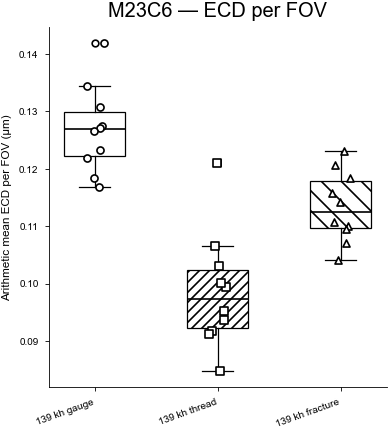

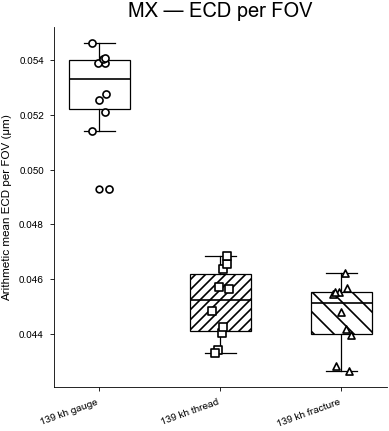

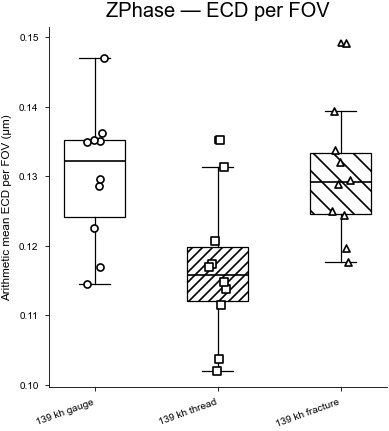

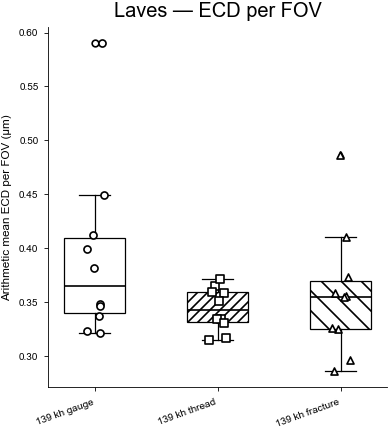

In [5]:
_BW_HATCHES = ["", "////", "\\\\", "xxxx", "....", "oooo", "////\\\\", "||", "--", "++"]
_BW_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "h", "*", "p"]

with journal_style(NATURE):
    for phase in PHASES:
        result = results_ecd[phase]
        summary = result.summary
        rng = np.random.default_rng(42)

        fig, ax = plt.subplots(figsize=(89 / 25.4, 89 / 25.4 * 1.1))
        for i, sr in enumerate(result.states):
            vals = summary[summary["state"] == sr.name]["amean"].values
            ax.boxplot(
                vals,
                positions=[i + 1],
                widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor="white", hatch=_BW_HATCHES[i % len(_BW_HATCHES)], linewidth=0.75),
                medianprops=dict(color="black", linewidth=1.0),
                whiskerprops=dict(color="black", linewidth=0.75),
                capprops=dict(color="black", linewidth=0.75),
                flierprops=dict(marker=_BW_MARKERS[i % len(_BW_MARKERS)], markerfacecolor="white",
                                markeredgecolor="black", markersize=4),
                manage_ticks=False,
            )
            jitter = rng.uniform(-0.08, 0.08, len(vals))
            ax.scatter(i + 1 + jitter, vals, marker=_BW_MARKERS[i % len(_BW_MARKERS)],
                       facecolors="white", edgecolors="black", s=18, zorder=3,
                       label=STATE_LABELS.get(sr.name, sr.name))

        ax.set_xticks(range(1, len(result.states) + 1))
        ax.set_xticklabels(
            [STATE_LABELS.get(sr.name, sr.name) for sr in result.states],
            rotation=20, ha="right",
        )
        ax.set_ylabel("Arithmetic mean ECD per FOV (µm)")
        ax.set_title(f"{phase} — ECD per FOV", pad=6)
        fig.tight_layout()
        save(fig, OUT_DIR / f"boxplot_ecd_{phase.replace(' ', '_')}", formats=["pdf", "png"])
        plt.show()

## 4. Combined multi-panel ECD figure

All three phases side-by-side for direct publication comparison.

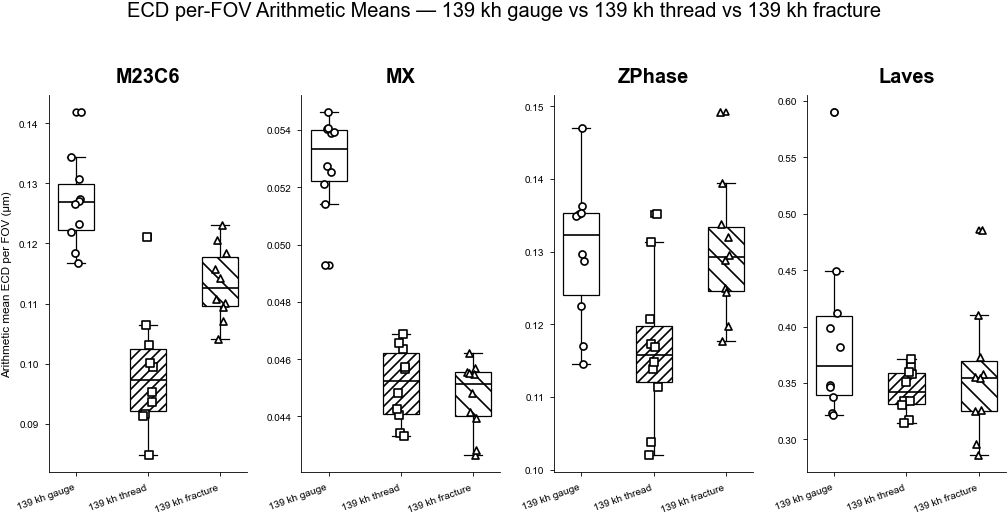

In [6]:
rng = np.random.default_rng(42)

with journal_style(NATURE):
    fig, axes = plt.subplots(
        1, len(PHASES),
        figsize=(len(PHASES) * 55 / 25.4, 55 / 25.4 * 2.0),
        sharey=False,
    )

    for ax, phase in zip(axes, PHASES):
        result = results_ecd[phase]
        summary = result.summary

        for i, sr in enumerate(result.states):
            vals = summary[summary["state"] == sr.name]["amean"].values
            ax.boxplot(
                vals,
                positions=[i + 1],
                widths=0.5,
                patch_artist=True,
                boxprops=dict(facecolor="white", hatch=_BW_HATCHES[i % len(_BW_HATCHES)], linewidth=0.75),
                medianprops=dict(color="black", linewidth=1.0),
                whiskerprops=dict(color="black", linewidth=0.75),
                capprops=dict(color="black", linewidth=0.75),
                flierprops=dict(marker=_BW_MARKERS[i % len(_BW_MARKERS)], markerfacecolor="white",
                                markeredgecolor="black", markersize=4),
                manage_ticks=False,
            )
            jitter = rng.uniform(-0.08, 0.08, len(vals))
            ax.scatter(i + 1 + jitter, vals, marker=_BW_MARKERS[i % len(_BW_MARKERS)],
                       facecolors="white", edgecolors="black", s=18, zorder=3,
                       label=STATE_LABELS.get(sr.name, sr.name) if phase == PHASES[0] else None)

        ax.set_xticks(range(1, len(result.states) + 1))
        ax.set_xticklabels(
            [STATE_LABELS.get(sr.name, sr.name) for sr in result.states],
            rotation=20, ha="right",
        )
        ax.set_title(phase, fontweight="bold", pad=8)

        if ax is axes[0]:
            ax.set_ylabel("Arithmetic mean ECD per FOV (µm)")

    state_label_str = " vs ".join(STATE_LABELS.get(s, s) for s in FILES)
    fig.suptitle(f"ECD per-FOV Arithmetic Means — {state_label_str}", y=1.02)
    fig.tight_layout()
    save(fig, OUT_DIR / "boxplot_ecd_combined", formats=["pdf", "png"])
    plt.show()

## 5. Summary table — mean of per-FOV means and ECD standard deviations

Each row is one (material state × phase) combination.  
`Mean ECD` is the mean of the per-FOV arithmetic means; `Std ECD` is their standard deviation.

In [7]:
rows = []
for phase in PHASES:
    s = results_ecd[phase].summary
    for state_name, grp in s.groupby("state"):
        rows.append({
            "State":         state_name,
            "Phase":         phase,
            "N FOVs":        len(grp),
            "N Features":    int(grp["n"].sum()),
            "Mean ECD (µm)": grp["amean"].mean(),
            "Std ECD (µm)":  grp["amean"].std(),
            "Min ECD (µm)":  grp["amean"].min(),
            "Max ECD (µm)":  grp["amean"].max(),
        })

summary_df = pd.DataFrame(rows).round(4)
display(summary_df)

csv_path = OUT_DIR / "summary_ecd_by_state_phase.csv"
summary_df.to_csv(csv_path, index=False)
print(f"Saved CSV → {csv_path}")

latex_str = to_latex(
    summary_df,
    OUT_DIR / "summary_ecd_by_state_phase.tex",
    caption="Mean per-FOV ECD statistics by material state and precipitate phase.",
    label="tab:ecd-summary",
    decimals=4,
)
print(f"Saved LaTeX → {OUT_DIR / 'summary_ecd_by_state_phase.tex'}")
print()
print(latex_str)

,State,Phase,N FOVs,N Features,Mean ECD (µm),Std ECD (µm),Min ECD (µm),Max ECD (µm)
0,GOO220_51,M23C6,10,6837,0.1268,0.0075,0.1168,0.1418
1,GOO220_52,M23C6,10,8605,0.0987,0.0101,0.0848,0.1210
2,GOO220_53,M23C6,10,7797,0.1134,0.0061,0.1042,0.1231
3,GOO220_51,MX,10,1153,0.0529,0.0016,0.0493,0.0546
4,GOO220_52,MX,10,1891,0.0451,0.0013,0.0433,0.0469
5,GOO220_53,MX,10,1492,0.0447,0.0012,0.0426,0.0462
6,GOO220_51,ZPhase,10,690,0.1301,0.0098,0.1145,0.1470
7,GOO220_52,ZPhase,10,268,0.1167,0.0105,0.1020,0.1352
8,GOO220_53,ZPhase,10,494,0.1300,0.0094,0.1177,0.1491
9,GOO220_51,Laves,10,132,0.3909,0.0814,0.3213,0.5899


Saved CSV → data\GOO220_mipar\summary_ecd_by_state_phase.csv
Saved LaTeX → data\GOO220_mipar\summary_ecd_by_state_phase.tex

\begin{table}
\centering
\caption{Mean per-FOV ECD statistics by material state and precipitate phase.}
\label{tab:ecd-summary}
\begin{tabular}{llrrrrrr}
\toprule
State & Phase & N FOVs & N Features & Mean ECD (\textmu{}m) & Std ECD (\textmu{}m) & Min ECD (\textmu{}m) & Max ECD (\textmu{}m) \\
\midrule
GOO220_51 & M23C6 & 10 & 6837 & 0.1268 & 0.0075 & 0.1168 & 0.1418 \\
GOO220_52 & M23C6 & 10 & 8605 & 0.0987 & 0.0101 & 0.0848 & 0.1210 \\
GOO220_53 & M23C6 & 10 & 7797 & 0.1134 & 0.0061 & 0.1042 & 0.1231 \\
GOO220_51 & MX & 10 & 1153 & 0.0529 & 0.0016 & 0.0493 & 0.0546 \\
GOO220_52 & MX & 10 & 1891 & 0.0451 & 0.0013 & 0.0433 & 0.0469 \\
GOO220_53 & MX & 10 & 1492 & 0.0447 & 0.0012 & 0.0426 & 0.0462 \\
GOO220_51 & ZPhase & 10 & 690 & 0.1301 & 0.0098 & 0.1145 & 0.1470 \\
GOO220_52 & ZPhase & 10 & 268 & 0.1167 & 0.0105 & 0.1020 & 0.1352 \\
GOO220_53 & ZPhase & 10 & 49

## 6. ECD comparison — pivoted view

Both states on the same row per phase for side-by-side comparison.

In [8]:
pivot = summary_df.pivot(
    index="Phase",
    columns="State",
    values=["Mean ECD (µm)", "Std ECD (µm)", "N Features"],
)
pivot.columns = [f"{metric} | {state}" for metric, state in pivot.columns]
pivot = pivot.reset_index().round(4)
display(pivot)

,Phase,Mean ECD (µm) | GOO220_51,Mean ECD (µm) | GOO220_52,Mean ECD (µm) | GOO220_53,Std ECD (µm) | GOO220_51,Std ECD (µm) | GOO220_52,Std ECD (µm) | GOO220_53,N Features | GOO220_51,N Features | GOO220_52,N Features | GOO220_53
0,Laves,0.3909,0.3433,0.3570,0.0814,0.0201,0.0583,132.0,147.0,101.0
1,M23C6,0.1268,0.0987,0.1134,0.0075,0.0101,0.0061,6837.0,8605.0,7797.0
2,MX,0.0529,0.0451,0.0447,0.0016,0.0013,0.0012,1153.0,1891.0,1492.0
3,ZPhase,0.1301,0.1167,0.1300,0.0098,0.0105,0.0094,690.0,268.0,494.0
